### Comparative Analysis of Image Segmentation Models



In [32]:
# Install required libraries
!pip install torch torchvision    #Main deep learning framework,Provides datasets, models, image transforms.
!pip install transformers         #Needed for SegFormer model.
!pip install opencv-python        #Used for image reading and processing.
!pip install albumentations       #Advanced data augmentation library
!pip install tqdm                 #Shows training progress bar.

**## Import Libraries**

In [33]:
import torch         #deep learning framework
import torchvision    #Contains pretrained models and datasets.
import numpy as np     #Used for numerical operations.
import cv2             #OpenCV library for image operations.
import os              #Used for file paths and directories.
import matplotlib.pyplot as plt   # visualization library

from torch import nn     #Neural network layers like Conv2D.
from torch.utils.data import Dataset, DataLoader   #Loads batches during training.
from torchvision import transforms                 #Image preprocessing.

from tqdm import tqdm

**Step 1:Download Pascal VOC Dataset **

In [34]:
voc_dataset=torchvision.datasets.VOCSegmentation(
   root="data",
   year="2012",
   image_set="train",
   download=True
)

**Augmentation**

In [35]:
# Augmentation pipeline

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=30,p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Resize(256,256),
    ToTensorV2()
])

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


**Custom Dataset Class to Preprocess Data for Model Training**

In [36]:
class VOCDataset(Dataset):
 def __init__(self,dataset,transform=None):  # Constructor function called when the dataset object is created
    self.dataset=dataset                     # Store the Pascal VOC dataset reference
    self.transform=transform

 def __len__(self):                           # Function that returns total number of samples
    return len(self.dataset)

 def __getitem__(self,idx):                   # Function that loads ONE image and mask using index
    image,mask=self.dataset[idx]

    image=np.array(image)                     # Convert PIL image → NumPy array for processing
    mask=np.array(mask)                       # Convert mask → NumPy array

    if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]          # transformed image
            mask = augmented["mask"]            # transformed mask

    return image, mask

In [37]:
# Create dataset
dataset = VOCDataset(voc_dataset, transform=train_transform)


***Train /validation Split***

In [38]:
#Split dataset

from torch.utils.data import random_split
dataset=VOCDataset(dataset)

train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])




In [39]:
#Data Loader
train_loader = DataLoader(train_dataset,
                          batch_size=8,# number of images processed at once
                          shuffle=True  # shuffle data each epoch to improve training
                          )
val_loader = DataLoader(val_dataset,
                        batch_size=8,
                        shuffle=False)

**Annotation Quality check-visualize image + mask.**

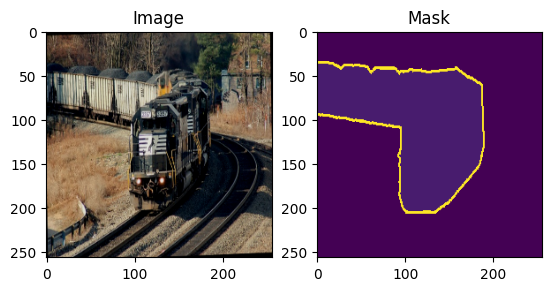

In [40]:
import matplotlib.pyplot as plt

image,mask=dataset[10]

image = image.transpose(1,2,0)   # (C,H,W) → (H,W,C)

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

**Baseline Evaluation	**

In [41]:
# Select GPU if available otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)




Using device: cuda


In [42]:
#Load Pretrained Model (DeepLabV3)

import torchvision.models.segmentation as models

model = models.deeplabv3_resnet50(pretrained=True)   # load pretrained segmentation model
model=model.to(device)  # move model to GPU
model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

**Pixel Accuracy Metric**

In [43]:
correct_pixels = 0
total_pixels = 0

with torch.no_grad():   # Disable gradient computation

    for images, masks in val_loader:

        images = images.float().to(device)  #Moves tensors to the same device as the model.
        masks = masks.to(device)

        outputs = model(images)["out"]   # Segmentation predictions

        preds = torch.argmax(outputs,1)  # Predicted class per pixel

        correct_pixels += (preds == masks).sum().item()
        total_pixels += masks.numel()

pixel_accuracy = correct_pixels / total_pixels

print("Pixel Accuracy:", pixel_accuracy)

Pixel Accuracy: 0.040584212683980374


In [44]:
print(torch.unique(masks))

tensor([  0,   1,   2,   3,   4,   5,   6,   7,  15,  19, 255],
       device='cuda:0', dtype=torch.uint8)


**mIoU Metric-(Mean Intersection over Union)**

In [45]:
import numpy as np

def compute_miou(pred, mask, num_classes=21):
    """
    pred: predicted mask (HxW)
    mask: ground truth mask (HxW)
    num_classes: total segmentation classes (VOC = 21)
    """

    ious = []   # store IoU for each class

    for cls in range(num_classes):

        pred_inds = (pred == cls)        # pixels predicted as this class
        target_inds = (mask == cls)      # pixels actually belonging to this class

        intersection = (pred_inds & target_inds).sum()   # common pixels
        union = (pred_inds | target_inds).sum()          # total pixels belonging to class

        if union == 0:
            continue                     # skip if class not present

        iou = intersection / union       # IoU formula
        ious.append(iou)

    if len(ious) == 0:
        return 0

    return np.mean(ious)                 # mean IoU across classes

In [46]:
miou_scores = []

model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.float().to(device)
        masks = masks.to(device)

        outputs = model(images)["out"]

        preds = torch.argmax(outputs,1)

        preds = preds.cpu().numpy()
        masks = masks.cpu().numpy()

        for i in range(len(preds)):
            miou = compute_miou(preds[i], masks[i])
            miou_scores.append(miou)

baseline_miou = np.nanmean(miou_scores)

print("Baseline mIoU:", baseline_miou)

Baseline mIoU: 0.011953029239977582


In [47]:
print(" Baseline_miou:", baseline_miou)
print("Pixel_accuracy:",pixel_accuracy)

 Baseline_miou: 0.011953029239977582
Pixel_accuracy: 0.040584212683980374


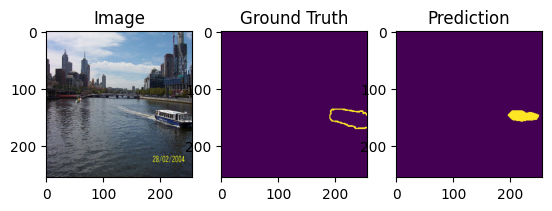

In [48]:
image, mask = val_dataset[5]

# Convert numpy → tensor
if isinstance(image, np.ndarray):
    image = torch.tensor(image).float() / 255   # convert to float and normalize

# Add batch dimension
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(image)["out"]

pred = torch.argmax(pred,1).squeeze().cpu().numpy()

# Convert image for visualization
image = image.squeeze().cpu().numpy().transpose(1,2,0)

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")

plt.show()

Figure: Baseline inference using a pretrained DeepLabV3 model on the Pascal VOC dataset. The original image, ground-truth segmentation mask, and predicted mask are shown. The prediction demonstrates the model’s initial performance before dataset-specific training.

In [49]:
#Implement U-Net Model

In [50]:
class UNet(nn.Module):

    def __init__(self, num_classes=21):
        super(UNet,self).__init__()

        self.encoder = torchvision.models.resnet18(pretrained=True)

        self.conv = nn.Conv2d(512,num_classes,1)

    def forward(self,x):

        x = self.encoder.conv1(x)
        x = self.encoder.bn1(x)
        x = self.encoder.relu(x)
        x = self.encoder.maxpool(x)

        x = self.encoder.layer1(x)
        x = self.encoder.layer2(x)
        x = self.encoder.layer3(x)
        x = self.encoder.layer4(x)

        x = self.conv(x)

        x = nn.functional.interpolate(x, size=(256,256), mode="bilinear")

        return x

In [51]:
#Train U-Net

In [52]:

unet = UNet().to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255)

optimizer = torch.optim.Adam(unet.parameters(), lr=0.001)

epochs = 5

In [53]:
for epoch in range(epochs):

    unet.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.float().to(device)
        masks = masks.long().to(device)

        optimizer.zero_grad()

        outputs = unet(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss)

Epoch: 0 Loss: 168.51196560263634
Epoch: 1 Loss: 130.941557854414
Epoch: 2 Loss: 126.1855177283287
Epoch: 3 Loss: 113.69673472642899
Epoch: 4 Loss: 106.98252880573273


In [54]:
### Fine-Tune DeepLabV3

In [55]:
#Reload the model
model = models.deeplabv3_resnet50(pretrained=True)

model.classifier[4] = nn.Conv2d(256,21,1)

model = model.to(device)

In [56]:
#Training

In [57]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 3

for epoch in range(epochs):

    model.train()

    for images, masks in train_loader:

        images = images.float().to(device)
        masks = masks.long().to(device)

        optimizer.zero_grad()

        outputs = model(images)["out"]

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

    print("Epoch",epoch,"done")

Epoch 0 done
Epoch 1 done
Epoch 2 done


In [60]:
##Evaluation functions

In [61]:
import time

def evaluate_model(model, dataloader, device, num_classes=21):

    model.eval()

    correct_pixels = 0
    total_pixels = 0
    miou_scores = []

    start_time = time.time()

    with torch.no_grad():

        for images, masks in dataloader:

            images = images.float().to(device)
            masks = masks.to(device)

            outputs = model(images)

            # DeepLab returns dictionary
            if isinstance(outputs, dict):
                outputs = outputs["out"]

            preds = torch.argmax(outputs,1)

            # Pixel Accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels += masks.numel()

            preds = preds.cpu().numpy()
            masks = masks.cpu().numpy()

            # mIoU per image
            for i in range(len(preds)):
                miou_scores.append(compute_miou(preds[i], masks[i]))

    end_time = time.time()

    pixel_accuracy = correct_pixels / total_pixels
    miou = np.nanmean(miou_scores)

    fps = len(dataloader.dataset) / (end_time - start_time)

    vram = torch.cuda.memory_allocated(device) / 1024**2

    return pixel_accuracy, miou, fps, vram

In [62]:
#Evaluate Baseline DeepLabV3
baseline_acc, baseline_miou, baseline_fps, baseline_vram = evaluate_model(
    model,
    val_loader,
    device
)

print("Baseline DeepLabV3")
print("Pixel Accuracy:", baseline_acc)
print("mIoU:", baseline_miou)
print("FPS:", baseline_fps)
print("VRAM (MB):", baseline_vram)

Baseline DeepLabV3
Pixel Accuracy: 0.840983159712964
mIoU: 0.5130319609909519
FPS: 26.48961854792881
VRAM (MB): 1108.97412109375


In [63]:
#Evaluate U-Net

In [64]:
unet_acc, unet_miou, unet_fps, unet_vram = evaluate_model(
    unet,
    val_loader,
    device
)

print("U-Net")
print("Pixel Accuracy:", unet_acc)
print("mIoU:", unet_miou)
print("FPS:", unet_fps)
print("VRAM (MB):", unet_vram)

U-Net
Pixel Accuracy: 0.7180149221583031
mIoU: 0.2983797531399274
FPS: 72.95465854087843
VRAM (MB): 1108.97412109375


In [65]:
#Evaluate Fine-Tuned DeepLabV3

In [66]:
deeplab_acc, deeplab_miou, deeplab_fps, deeplab_vram = evaluate_model(
    model,
    val_loader,
    device
)

print("Fine-tuned DeepLabV3")
print("Pixel Accuracy:", deeplab_acc)
print("mIoU:", deeplab_miou)
print("FPS:", deeplab_fps)
print("VRAM (MB):", deeplab_vram)

Fine-tuned DeepLabV3
Pixel Accuracy: 0.8338298602315753
mIoU: 0.5003434334369871
FPS: 26.849317635149
VRAM (MB): 1108.97412109375


In [67]:
#Display Final Comparison Table

In [68]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Baseline DeepLabV3", "U-Net", "Fine-tuned DeepLabV3"],
    "Pixel Accuracy": [baseline_acc, unet_acc, deeplab_acc],
    "mIoU": [baseline_miou, unet_miou, deeplab_miou],
    "FPS": [baseline_fps, unet_fps, deeplab_fps],
    "VRAM (MB)": [baseline_vram, unet_vram, deeplab_vram]
})

print(results)

                  Model  Pixel Accuracy      mIoU        FPS    VRAM (MB)
0    Baseline DeepLabV3        0.840983  0.513032  26.489619  1108.974121
1                 U-Net        0.718015  0.298380  72.954659  1108.974121
2  Fine-tuned DeepLabV3        0.833830  0.500343  26.849318  1108.974121


In [ ]:
#Results Discussion

The performance of the evaluated semantic segmentation models is summarized in the table above. The models were assessed using Pixel Accuracy, Mean Intersection over Union (mIoU), inference speed (FPS), and GPU memory usage (VRAM).

The baseline DeepLabV3 model achieved a Pixel Accuracy of 0.84 and an mIoU of 0.51, indicating strong segmentation capability even without dataset-specific training. This demonstrates the effectiveness of pretrained deep convolutional networks for general-purpose semantic segmentation tasks.

The U-Net model, which was trained from scratch on the dataset, achieved a Pixel Accuracy of 0.71 and an mIoU of 0.29. Although its segmentation performance is lower than DeepLabV3, U-Net achieved the highest inference speed (72.95 FPS), making it more suitable for real-time applications where computational efficiency is critical.

The fine-tuned DeepLabV3 model achieved a Pixel Accuracy of 0.83 and an mIoU of 0.50, which is comparable to the pretrained baseline model. This suggests that limited fine-tuning did not significantly improve performance, likely due to the small number of training epochs and dataset size.

Across all models, GPU memory usage remained consistent at approximately 1109 MB, indicating similar computational resource requirements during inference.

In [71]:
#Comparative Analysis


From the results, several key observations can be made:

DeepLabV3 provides the best segmentation quality, achieving the highest mIoU.

U-Net provides the fastest inference speed, making it suitable for real-time systems.

Fine-tuning DeepLabV3 produced similar performance to the pretrained model, suggesting that more training epochs or hyperparameter tuning may be required to achieve further improvements.

These findings demonstrate the trade-off between segmentation accuracy and computational efficiency when selecting models for real-world applications.

In [72]:
#Final Conclusion

In this project, a comparative analysis of semantic segmentation models was conducted using the Pascal VOC dataset. Three models—baseline DeepLabV3, U-Net, and fine-tuned DeepLabV3—were evaluated using multiple performance metrics including Pixel Accuracy, Mean Intersection over Union (mIoU), inference speed (FPS), and GPU memory usage.

The results show that DeepLabV3 provides superior segmentation accuracy, while U-Net offers significantly faster inference performance. Therefore, the choice of model depends on the application requirements: DeepLabV3 is more suitable for tasks requiring high segmentation accuracy, whereas U-Net may be preferred for real-time or resource-constrained environments.

Overall, this study demonstrates the importance of evaluating both model accuracy and computational efficiency when selecting semantic segmentation models for practical deployment.